<a href="https://colab.research.google.com/github/IrinaKusyakinamew/LR6/blob/master/%D0%A1%D1%82%D0%B0%D1%82%D0%B8%D1%81%D1%82%D0%B8%D0%BA%D0%B0_ipynb%22.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Импорт библиотек и данных

In [1]:
import pandas as pd
import numpy as np

https://drive.google.com/file/d/1zLKWeJ_OZjxuKlP561-GopniC0_Pt_X6/view?usp=sharing

In [2]:
! gdown --id 1zLKWeJ_OZjxuKlP561-GopniC0_Pt_X6

/usr/local/lib/python3.11/dist-packages/gdown/__main__.py:140: FutureWarning: Option `--id` was deprecated in version 4.3.1 and will be removed in 5.0. You don't need to pass it anymore to use a file ID.
  warnings.warn(
Downloading...
From: https://drive.google.com/uc?id=1zLKWeJ_OZjxuKlP561-GopniC0_Pt_X6
To: /content/age_children_income_1000.csv
100% 38.8k/38.8k [00:00<00:00, 60.5MB/s]


In [3]:
df = pd.read_csv('/content/age_children_income_1000.csv')

In [ ]:
df

,age,number_of_children,income
0,42.772420,0,34396.537188
1,29.561090,0,183350.052521
2,54.380735,0,53689.856555
3,42.551689,0,109080.913926
4,38.713080,0,153612.343419
...,...,...,...
995,36.281055,0,128647.922872
996,18.472716,0,67204.531673
997,40.547748,0,139432.757984
998,24.791760,1,137526.452334


Чтобы отобразить нужное количество строк, можно установить максимальное количество отображаемых строк

In [ ]:
pd.options.display.max_rows = 1000

Однако проанализировать такой сырой датасет очень сложно

In [ ]:
df

,age,number_of_children,income
0,42.772420,0,34396.537188
1,29.561090,0,183350.052521
2,54.380735,0,53689.856555
3,42.551689,0,109080.913926
4,38.713080,0,153612.343419
5,54.643163,0,114836.781583
6,27.372789,0,132556.578233
7,28.350204,2,79137.007762
8,33.676546,0,193091.364233
9,25.659336,1,124276.826089


Выведем первые 5 строк

In [ ]:
df.head()

,age,number_of_children,income
0,42.772420,0,34396.537188
1,29.561090,0,183350.052521
2,54.380735,0,53689.856555
3,42.551689,0,109080.913926
4,38.713080,0,153612.343419


В данном датафрейме age, income - непрерывные переменные, а number_of_children - дискретная (категориальная)

# Анализ дискретной переменной

Посмотрим, какие значения может принимать дискретная переменная при помощи value_counts

Получим распределение дискретной переменной number_of_children

In [ ]:
df['number_of_children'].value_counts()

,count
number_of_children,
0,658
1,226
2,94
3,20
5,1
4,1


Посмотреть распределение дискретной переменной в долях (проценты в формате десятичных дробей) можно, если внутри value_counts в качестве параметра указать normalize=True

In [ ]:
df['number_of_children'].value_counts(normalize=True)

,proportion
number_of_children,
0,0.658
1,0.226
2,0.094
3,0.020
5,0.001
4,0.001


Визуализацию переменной осуществляют в виде гистограммы, используя метод hist

In [ ]:
import matplotlib.pyplot as plt
plt.style.use('dark_background')

<Axes: >

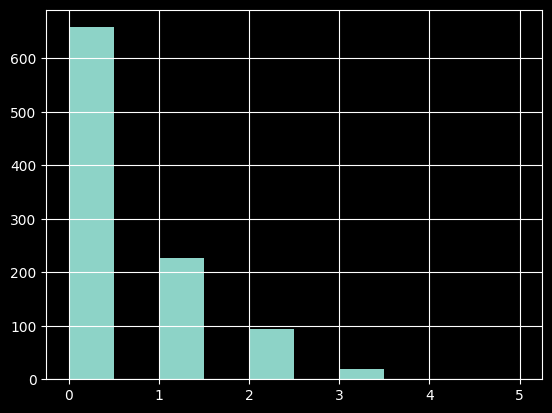

In [ ]:
df['number_of_children'].hist()

Как на гистограмме отобразить процентное содержание? Использовать библиотеку seaborn

In [ ]:
import seaborn as sns

Используем метод histplot и параметр stat='probability' импортированной библиотеки sns

<Axes: xlabel='number_of_children', ylabel='Probability'>

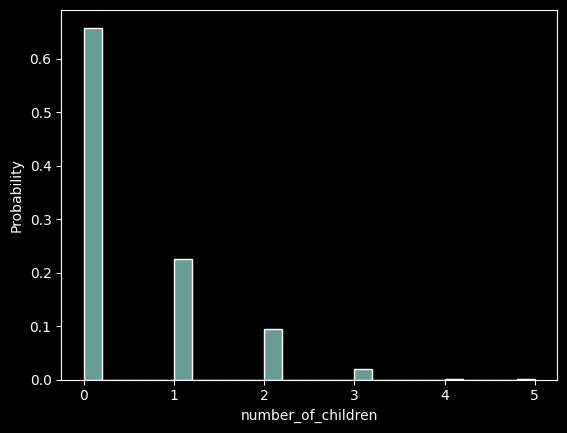

In [ ]:
sns.histplot(df['number_of_children'], stat='probability')

# Анализ непрерывной перемменной

Анализировать непрервыную переменную сложнее, чем дискретную

Метод value_counts в случае с непрервыной переменной не особо полезен, поскольку каждое значение в столбце age уникально

In [ ]:
df['age'].value_counts()

,count
age,
46.662848,1
42.772420,1
29.561090,1
54.380735,1
42.551689,1
38.713080,1
54.643163,1
27.372789,1
29.669609,1


Поэтому чтобы посмотреть на распределение непрерывной переменной, необходимо предварительно разбить ее на интервалы и посчитать количество наблюдений в каждом интервале

Сделать это можно при помощи метода hist, который разобьет переменную по умолчанию на 10 равных диапазонов и выведет результат в виде диаграммы

<Axes: >

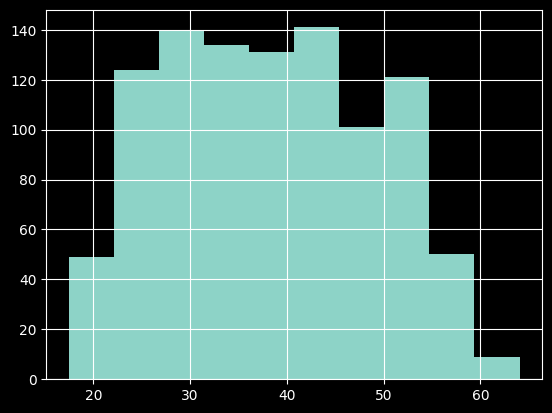

In [ ]:
df['age'].hist()

Ту же самую информацию можно получить, используя библиотеку seaborn

<Axes: xlabel='age', ylabel='Count'>

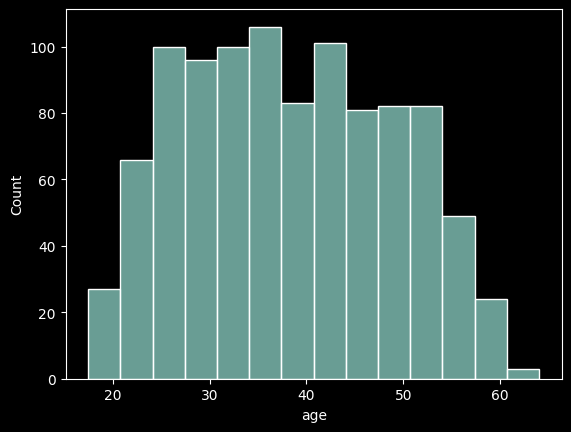

In [ ]:
sns.histplot(df['age'])

Метод cut используют не только, чтобы разбить переменную на равные диапазоны, но и чтобы посмотреть количественное содрежание для каждого диапазона

In [ ]:
df['age_bin'] = pd.cut(df['age'], 10)

Для анализа количественного содержания используют groupby, строящий сводную диаграмму для столбцов и выводящий определенную метрику на их пересечении (в нашем случае количество)

Метрика count для анализа количественного содержания

In [ ]:
df.groupby('age_bin')['age'].count()

/tmp/ipython-input-930591620.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_bin')['age'].count()


,age
age_bin,
"(17.402, 22.107]",49
"(22.107, 26.766]",124
"(26.766, 31.425]",140
"(31.425, 36.084]",134
"(36.084, 40.743]",131
"(40.743, 45.401]",141
"(45.401, 50.06]",101
"(50.06, 54.719]",121
"(54.719, 59.378]",50


# Другие метрики для анализа переменных

## Метрика - среднее значение

Метрика среднее значение mean для дискретной переменной

In [ ]:
float(df['number_of_children'].mean())

0.483

Метрика среднее значение mean для непрерывной переменной

In [ ]:
float(df['age'].mean())

38.31925590719966

Однако среднее значение может неадекватно отражать действительность

Пример: посчитаем ЗП людей, у которых она на примерно одном уровне

In [ ]:
salary = pd.Series([30, 30, 40, 60, 50])

Получим вполне реальное среднее значение

In [ ]:
float(salary.mean())

42.0

А теперь добавим в список ЗП миллиардера

In [ ]:
salary = pd.Series([30, 30, 40, 60, 50, 999999999999])

Теперь средняя зарплата станет очень большой. Но это не соответствует реальности, в которой 5 человек из 6 по меркам ЗП миллиардера получают сущие копейки

In [ ]:
float(salary.mean())

166666666701.5

Таким образом, не всегда среднее значение объективно отражает действительность. Поэтому важно корректно использовать эту метрику

В данном случае лучше посмотреть на распределение зарплаты salary на гистограмме

В результате получили "жирный хвост", или перекошенное распределение

<Axes: >

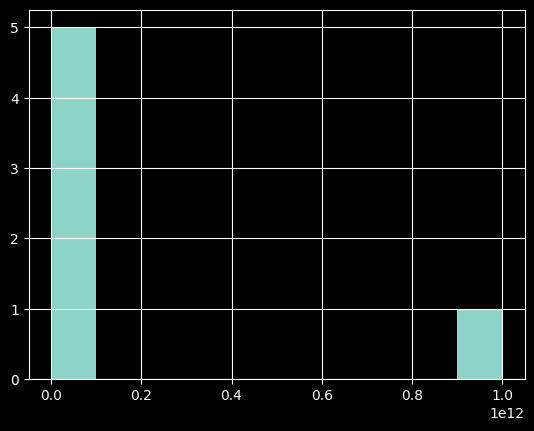

In [ ]:
salary.hist()

## Метрика - медиана

Медиана - значение в середине упорядоченного диапазона

Еще одно определение: медиана - это значение переменной, ниже которого имеют 50% выборки, т.е. медиана - это "50-й процентиль"

In [ ]:
salary = pd.Series([30, 30, 40, 60, 50])

Для диапазона, длина которого четная, медиана - это значение в самой середине диапазона

In [ ]:
salary.sort_values()

,0
0,30
1,30
2,40
4,50
3,60
5,999999999999


In [ ]:
salary.median()

40.0

Суть метрики медиана отражается в предложении: у 50% наблюдений в выборке значение переменной ЗП меньше, чем медиана

Для диапазона, длина которого нечетная, медиана - это среднее арифметическое между двумя значениями из середины диапазона. Однако такое утверждение характерно, как правило, для больших диапазонов

In [ ]:
salary = pd.Series([30, 30, 40, 60, 50, 999999999999])

In [ ]:
salary.sort_values()

,0
0,30
1,30
2,40
4,50
3,60
5,999999999999


In [ ]:
salary.median()

45.0

Теперь проверим значение медианы для df и проверим, будет ли 50% наблюдений меньше, чем медиана или нет

In [ ]:
df['income'].median()

114586.57093898312

In [ ]:
float((df['income'] < df['income'].median()).mean())

0.5

Вывод: ровно 50% наблюдений по income меньше, чем медианное значение

## Метрика - мода

Мода - самое часто встречающееся в диапазоне значение

Для категориальной (дискретной) переменной мода - это топ 1 в value_counts

In [ ]:
df['number_of_children'].value_counts()

,count
number_of_children,
0,658
1,226
2,94
3,20
5,1
4,1


Получили моду: 0

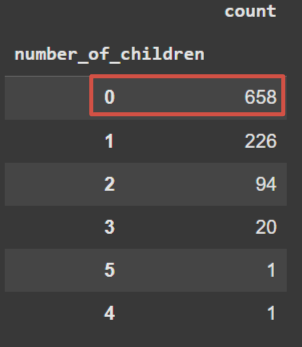

In [ ]:
df['number_of_children'].mode()

,number_of_children
0,0


Для непрерывной переменной мода не имеет никакого смысла, так как там все значения уникальны и будут модой

In [ ]:
df['age'].mode()

,age
0,17.448452
1,17.945699
2,18.221844
3,18.245730
4,18.327301
5,18.417653
6,18.472716
7,18.866609
8,19.034861
9,19.183945


Желательно смотреть и на среднее значение, и на медиану. Делается это при помощи функции agg

In [ ]:
df['income'].agg(['mean', 'median'])

,income
mean,129415.746378
median,114586.570939


По гистограмме можно сделать вывод о том, что распределение ЗП income неравномерное ("перекошенное")

<Axes: >

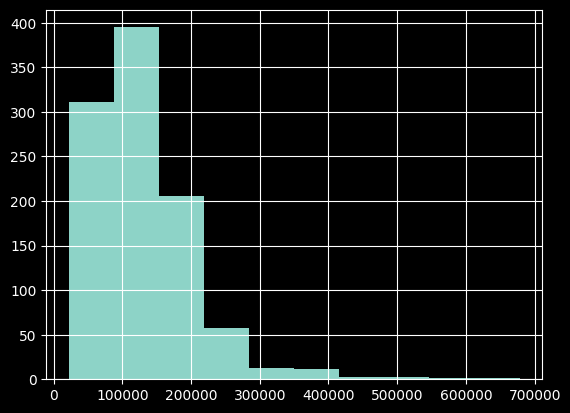

In [ ]:
df['income'].hist()

# Метрика - процентили

In [ ]:
True+True

2

In [ ]:
(True+True+False)/3

0.6666666666666666

Выведем для каждой строки в столбце income значение True/False, в зависимости от выполнения/невыполнения условия

In [ ]:
df['income'] < 114586.570939

,income
0,True
1,False
2,True
3,True
4,False
5,False
6,False
7,True
8,False
9,False


Чтобы посчитать среднее значение записей, в которых выполняется заданное условие (результат True), используем метрику mean

Среднее значение записей, где выполняется условие: сумма всех True/количество всех записей в столбце

In [ ]:
float((df['income'] < 114586.570939).mean())

0.5

Можно попытаться подобрать значение, чтобы выводился нужный процент

In [ ]:
float((df['income'] < 100000).mean())

0.397

Вывод: ЗП < 100000 у примерно 40% людей

Другой способ вычисления нужного процентиля - при помощи квантиля

In [ ]:
float(df['income'].quantile(0.4))

100512.68685217279

Проверим действительно ли полученное значение даст нужный 40-й процентиль

In [ ]:
(df['income'] < df['income'].quantile(0.4)).mean()

np.float64(0.4)

Квантиль и процентиль - практически то же самое, только процентиль - это квантиль * 100

Квартиль - важный процентиль. Выделяют три квартиля:
1. 25-й (первый)
2. 50-й (медианный)
3. 75-й

In [ ]:
float(df['income'].quantile(0.25))

79594.0403996465

In [ ]:
float(df['income'].quantile(0.5))

114586.57093898312

In [ ]:
float(df['income'].quantile(0.75))

162888.8910808624

В разной статистической литературе определения процентилей и квантилей может отличаться, поэтому лучше проверять их формулами

Для каждого значения можно посчитать score - величину, близкую к процентилю

In [ ]:
df['age'].rank(pct=True).head()

,age
0,0.639
1,0.257
2,0.936
3,0.634
4,0.521


In [ ]:
df['pct'] = df['age'].rank(pct=True).head()

In [ ]:
df.head()

,age,number_of_children,income,age_bin,pct
0,42.772420,0,34396.537188,"(40.743, 45.401]",0.639
1,29.561090,0,183350.052521,"(26.766, 31.425]",0.257
2,54.380735,0,53689.856555,"(50.06, 54.719]",0.936
3,42.551689,0,109080.913926,"(40.743, 45.401]",0.634
4,38.713080,0,153612.343419,"(36.084, 40.743]",0.521


Проверим полученные процентили

In [ ]:
float((df['age'] < 42.772420).mean())

0.638

Вывод: 0,638 != 0,639 => есть небольшое расхождение.
64% людей имеют меньший возраст, чем человек с возрастом 42,772420

# Boxplot

Боксплот используют для симметричных выборок, т.е. для нормального распределения

Для анализа сырых данных боксплот не всегда удобен

<Axes: >

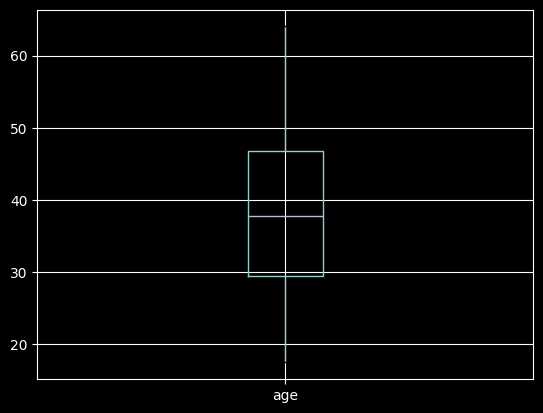

In [ ]:
df.boxplot('age')

Boxplot изображает графически важные процентили: первый, второй, третий квартили, а также усы

Усы - это 1,5 межквартильных размаха. Граница уса не может быть больше межквартильного размаха

Межквартильный размах - это расстояние между первым и третьим квартилями

Все, что находится за пределами усов - выброс для боксплота

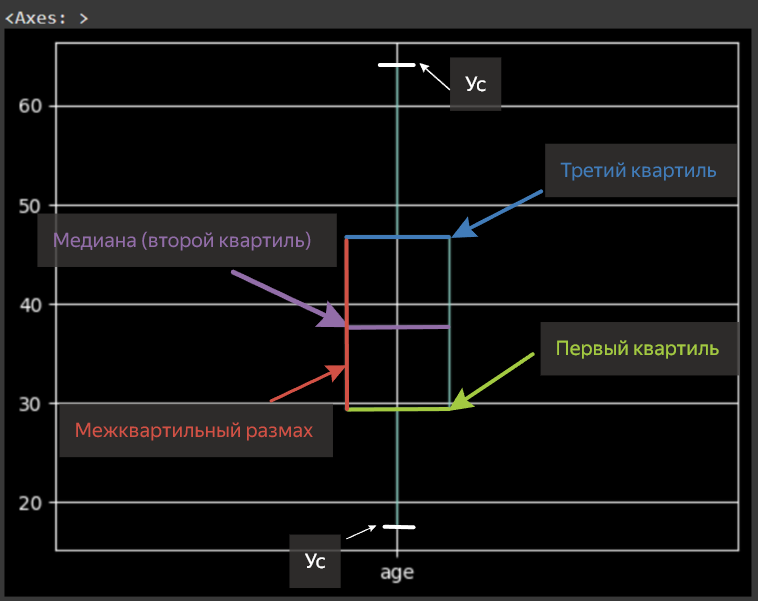

Не всегда boxplot удобно использовать, особенно если распределение перекошено

<Axes: >

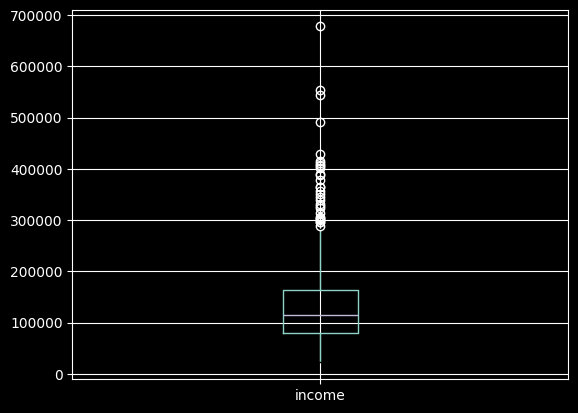

In [ ]:
df.boxplot('income')

Можно посмотреть горизонтальное отображение боксплота, используя библиотеку sns (seaborn)

<Axes: xlabel='income'>

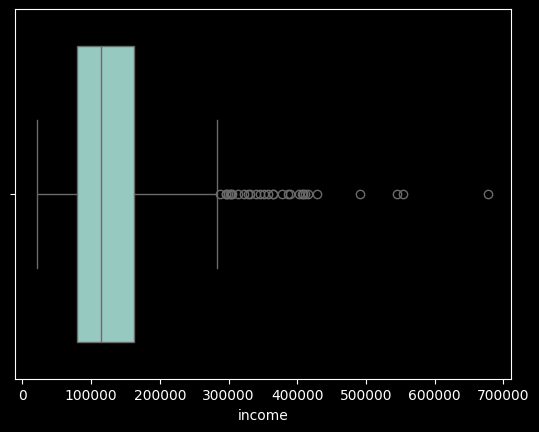

In [ ]:
sns.boxplot(df['income'], orient='h')

<Axes: >

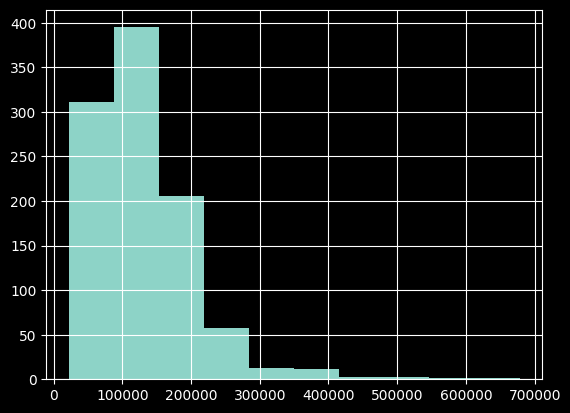

In [ ]:
df['income'].hist()

Вывод: горизонтальный боксплот и гистограмма показывают схожую структуру - большая часть данных сосредоточена в диапазоне до 300000, остальные данные считаются выбросами

# Describe

describe используют для представления данных столбца в табличной форме

In [ ]:
df['income'].describe()

,income
count,1000.000000
mean,129415.746378
std,71251.620971
min,21943.855414
25%,79594.040400
50%,114586.570939
75%,162888.891081
max,678006.351857


## Метрика - стандартное отклонение

Ограничим количество выводимых строк для удобства

In [ ]:
pd.options.display.max_rows = 100

Сначала посчитаем среднее значение для столбца income

In [ ]:
float(df['income'].mean())

129415.74637843431

Затем посчитаем отклонение значений столбца income от среднего значения как разность между этими значениями

In [ ]:
df['income'] - df['income'].mean()

,income
0,-95019.209190
1,53934.306143
2,-75725.889823
3,-20334.832452
4,24196.597041
...,...
995,-767.823506
996,-62211.214705
997,10017.011605
998,8110.705955


Как оценить отклонение от среднего значения? Построить гистограмму

<Axes: >

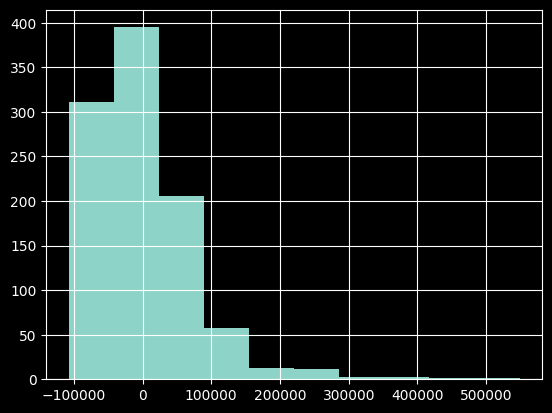

In [ ]:
(df['income'] - df['income'].mean()).hist()

Теперь посчитаем среднее значение для всех отклонений

In [ ]:
(df['income'] - df['income'].mean()).mean()

np.float64(5.1222741603851315e-12)

Получили значение, стремящееся к нулю. Это произошло из-за того, что в столбце отклонений есть как положительные, так и отрицательные значения, в сумме они компенсировали разницу в 0

Поэтому чтобы получить корректное значение среднего отклонения, возьмем значения из столбца отклонений от среднего по модулю и уже потом посчитаем среднее значение для всего столбца отклонений

In [ ]:
float((df['income'] - df['income'].mean()).abs().mean())

51910.29730549474

Однако посчитанное отклонение является средним, а не стандартным отклонением

Дисперсия - это квадрат среднего квадратичного отклонения

In [6]:
float(((df['income'] - df['income'].mean())**2).mean())

5071716697.45695

Стандартное отклонение - это квадратный корень из дисперсии

Теперь посчитаем стандартное отклонение. Получили почти то же значение, что в таблице describe

In [5]:
float(np.sqrt(((df['income'] - df['income'].mean())**2).mean()))

71215.98624927517

Формула ниже считает квадраты отклонений от среднего значения

In [7]:
((df['income'] - df['income'].mean())**2)

,income
0,9.028650e+09
1,2.908909e+09
2,5.734410e+09
3,4.135054e+08
4,5.854753e+08
...,...
995,5.895529e+05
996,3.870235e+09
997,1.003405e+08
998,6.578355e+07


Чтобы получить точное значение стандартного отклонения, при подсчете mean нужно делить сумму на (количество всех строк -1)

In [10]:
float(np.sqrt(((df['income'] - df['income'].mean())**2).sum()/(len(df)-1)))

71251.62097066913

In [11]:
df['income'].describe()

,income
count,1000.000000
mean,129415.746378
std,71251.620971
min,21943.855414
25%,79594.040400
50%,114586.570939
75%,162888.891081
max,678006.351857


Стандартное отклонение не помогает в анализе данных

Научные статьи по статистике: https://arxiv.org/pdf/2001.10488

# Метрика - корреляция

Корреляция может показать линейную взаимосвязь между двумя переменными

In [14]:
df[['age', 'income']].corr()

,age,income
age,1.000000,-0.048164
income,-0.048164,1.000000


На первый взгляд, связи между переменными age и income нет

Однако все равно стоит проверить выводы при помощи построения сводной таблицы

Но сначала разобьем непрерывную переменную age на 10 интервалов

In [18]:
df['age_bin'] = pd.cut(df['age'], 10)

In [20]:
df.groupby('age_bin')['income'].agg(['count', 'mean', 'median'])

/tmp/ipython-input-2890831652.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_bin')['income'].agg(['count', 'mean', 'median'])


,count,mean,median
age_bin,,,
"(17.402, 22.107]",49,104319.382165,88163.526875
"(22.107, 26.766]",124,133775.791324,125960.906191
"(26.766, 31.425]",140,130575.738767,114947.477353
"(31.425, 36.084]",134,135654.848704,118368.874351
"(36.084, 40.743]",131,134457.081592,128647.922872
"(40.743, 45.401]",141,139697.676942,123441.920529
"(45.401, 50.06]",101,142814.622910,122199.047306
"(50.06, 54.719]",121,112563.104588,95443.103632
"(54.719, 59.378]",50,104040.538214,91602.734609


Построим график по медиане

/tmp/ipython-input-4264205019.py:1: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  df.groupby('age_bin')['income'].median().plot(rot=45, ylim=0)


<Axes: xlabel='age_bin'>

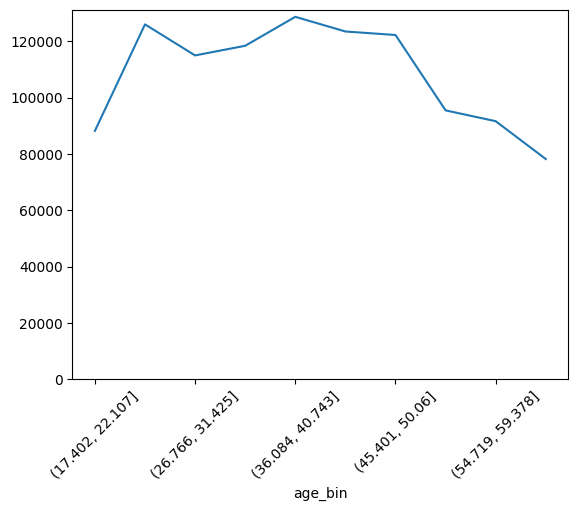

In [25]:
df.groupby('age_bin')['income'].median().plot(rot=45, ylim=0)